# 一、传统的DBN

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import os
import scipy.io
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path
notebook_path = Path(sys.argv[0]).parent if "ipykernel" in sys.argv[0] else Path.cwd()
sys.path.append(str(notebook_path))
from utils import use  
from utils import dbn_model as dbnm


In [4]:
class RBM(nn.Module):
    def __init__(self, n_vis, n_hid):
        super(RBM, self).__init__()
        self.n_vis = n_vis
        self.n_hid = n_hid

        # 权重 & 偏置参数
        self.W = nn.Parameter(torch.randn(n_vis, n_hid) * 0.01)
        self.v_bias = nn.Parameter(torch.zeros(n_vis))
        self.h_bias = nn.Parameter(torch.zeros(n_hid))

    def sample_from_p(self, p):
        # 对概率进行伯努利采样
        return torch.bernoulli(p)

    def v_to_h(self, v):
        # 由可视层到隐层的条件概率
        p_h = torch.sigmoid(torch.matmul(v, self.W) + self.h_bias)
        return p_h

    def h_to_v(self, h):
        # 由隐层到可视层的条件概率
        p_v = torch.sigmoid(torch.matmul(h, self.W.t()) + self.v_bias)
        return p_v

    def forward(self, v):
        # 用于前向推理：给一个 v，返回隐层激活概率
        p_h = self.v_to_h(v)
        return p_h

    def contrastive_divergence(self, v0, lr=1e-3, k=1):
        """
        v0: [batch_size, n_vis]
        k : CD-k，这里默认 CD-1
        """
        v = v0
        # 正相（positive phase）
        p_h0 = self.v_to_h(v0)
        h0 = self.sample_from_p(p_h0)

        # Gibbs 采样
        for _ in range(k):
            p_v = self.h_to_v(h0)
            v = self.sample_from_p(p_v)
            p_h = self.v_to_h(v)
            h = self.sample_from_p(p_h)

        # 负相（negative phase）
        v_k = v
        p_hk = p_h

        # 更新梯度：dW ∝ v0^T h0 - v_k^T h_k
        positive_grad = torch.matmul(v0.t(), p_h0)
        negative_grad = torch.matmul(v_k.t(), p_hk)

        # 手动更新参数（最原始的写法，便于理解）
        self.W.data += lr * (positive_grad - negative_grad) / v0.size(0)
        self.v_bias.data += lr * torch.mean(v0 - v_k, dim=0)
        self.h_bias.data += lr * torch.mean(p_h0 - p_hk, dim=0)

        # 返回一个重构误差方便观察
        loss = torch.mean((v0 - v_k) ** 2)
        return loss.item()

class DBNClassifier(nn.Module):
    def __init__(self, layer_sizes, n_classes):
        """
        layer_sizes: [input_dim, hid1, hid2, ...]
        n_classes : 分类类别数
        """
        super(DBNClassifier, self).__init__()
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes) - 1

        # 创建若干个 RBM，用于无监督预训练
        self.rbms = nn.ModuleList([
            RBM(layer_sizes[i], layer_sizes[i+1])
            for i in range(self.n_layers)
        ])

        # 用同样的结构创建一个前馈神经网络，用于监督微调
        modules = []
        for i in range(self.n_layers):
            modules.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            modules.append(nn.ReLU())
        # 最后一层分类头
        modules.append(nn.Linear(layer_sizes[-1], n_classes))
        self.classifier = nn.Sequential(*modules)

    def forward(self, x):
        return self.classifier(x)

    @torch.no_grad()
    def init_from_rbms(self):
        """
        用预训练好的 RBM 权重初始化前馈网络前几层。
        """
        linear_layers = [m for m in self.classifier.modules()
                         if isinstance(m, nn.Linear)]

        for i, rbm in enumerate(self.rbms):  # 最后一层 RBM 可选
            linear_layers[i].weight.data = rbm.W.data.t().clone()
            linear_layers[i].bias.data = rbm.h_bias.data.clone()


In [28]:
def pretrain_dbn(dbn, train_loader, n_epochs=5, lr=1e-3, device="gpu"):
    dbn.to(device)
    for layer_idx, rbm in enumerate(dbn.rbms):
        print(f"Pretraining RBM layer {layer_idx+1}/{dbn.n_layers}")
        for epoch in range(n_epochs):
            epoch_loss = 0.0
            for batch_x, _ in train_loader:   # 无监督，不用标签
                v = batch_x.to(device)
                # 逐层传递：当前层的输入是前面所有 RBM 的隐层输出
                with torch.no_grad():
                    for prev_idx in range(layer_idx):
                        v = dbn.rbms[prev_idx].v_to_h(v)
                        v = (v > 0.5).float()  # 二值化一下

                loss = rbm.contrastive_divergence(v, lr=lr, k=1)
                epoch_loss += loss * v.size(0)
            print(f"  Epoch {epoch+1}/{n_epochs}, recon loss = {epoch_loss / len(train_loader.dataset):.6f}")
    # 预训练完成后，用 RBM 初始化前馈分类器权重
    dbn.init_from_rbms()

def finetune_dbn(dbn, train_loader, test_loader=None,
                 n_epochs=20, lr=1e-3, device="cpu"):
    dbn.to(device)
    optimizer = torch.optim.Adam(dbn.classifier.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(n_epochs):
        dbn.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = dbn(batch_x)
            loss = criterion(logits, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == batch_y).sum().item()
            total_samples += batch_x.size(0)

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        print(f"[Fine-tune] Epoch {epoch+1}/{n_epochs}, "
              f"loss={train_loss:.4f}, acc={train_acc:.4f}")

        if test_loader is not None:
            acc, _ = evaluate_dbn(dbn, test_loader, device=device)
            test_accs.append(acc)

    return train_losses, train_accs, test_accs



def evaluate_dbn(dbn, data_loader, device="cpu"):
    dbn.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = dbn(batch_x)
            preds = logits.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(batch_y.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    acc = (y_true == y_pred).mean()
    f1 = f1_score(y_true, y_pred, average="macro")

    print(f"  [Eval] acc={acc:.4f}, f1_macro={f1:.4f}")
    return acc, f1

def plot_dbn_curves(train_losses, train_accs, test_accs=None,
                    save_path=None, figsize=(6,4), dpi=300):
    epochs = range(1, len(train_losses)+1)

    fig, ax1 = plt.subplots(figsize=figsize, dpi=dpi)

    ax1.plot(epochs, train_losses, label="Train loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.tick_params(axis="y")

    ax2 = ax1.twinx()
    ax2.plot(epochs, train_accs, label="Train acc", linestyle="--")
    if test_accs is not None and len(test_accs) == len(train_losses):
        ax2.plot(epochs, test_accs, label="Test acc", linestyle=":")
    ax2.set_ylabel("Accuracy")

    # 合并图例
    lines, labels = [], []
    for ax in [ax1, ax2]:
        l, lab = ax.get_legend_handles_labels()
        lines += l
        labels += lab
    ax1.legend(lines, labels, loc="lower right", frameon=False)

    for spine in ["top", "right"]:
        ax1.spines[spine].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[plot_dbn_curves] 图已保存到: {save_path}")

    plt.show()

In [29]:
import pandas as pd 
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)

In [22]:
X, y, feature_cols = dbnm.build_X_y_from_feature_df(feature_df, label_col='label')
sorce_col='sorce'
stratify = True
test_size = 0.2
random_state = 0

if sorce_col is not None and stratify:
    print('不同来源的训练和测试')
    # 使用 sorce_col 进行分层，并确保数据来源在训练集和测试集之间不重叠
    # 我们根据 sorce_col 的唯一值进行划分
    unique_sources = feature_df[sorce_col].unique()
    train_sources, test_sources = train_test_split(unique_sources, test_size=test_size, random_state=random_state)
    print('训练集样本：',train_sources)
    print('测试集样本：',test_sources)
    # 通过源信息划分训练集和测试集
    train_mask = feature_df[sorce_col].isin(train_sources)
    test_mask = feature_df[sorce_col].isin(test_sources)

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
else:
    # 没有指定 sorce_col 或 stratify 为 False，普通划分
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
print(f"特征维度: {X_train.shape[1]}")
print()

不同来源的训练和测试
训练集样本： ['X209' 'X285' 'X058' 'X199' 'X059' 'X288' 'X236' 'X234' 'X133' 'X108'
 'X145' 'X159' 'X212' 'X222' 'X297' 'X276' 'X050' 'X158' 'X105' 'X259'
 'X249' 'X283' 'X130' 'X316' 'X312' 'X286' 'X281' 'X275' 'X311' 'X310'
 'X287' 'X261' 'X223' 'X282' 'X298' 'X313' 'X224' 'X186' 'X293' 'X299'
 'X273' 'X188' 'X292' 'X305' 'X132' 'X048' 'X197' 'X160' 'X306' 'X260'
 'X280' 'X057' 'X277' 'X315' 'X185' 'X247' 'X248' 'X210' 'X270' 'X146'
 'X056' 'X131' 'X295' 'X301' 'X198' 'X119' 'X309' 'X170' 'X049' 'X278'
 'X258' 'X156' 'X211' 'X237' 'X300' 'X271' 'X200' 'X291' 'X246' 'X172'
 'X169' 'X120' 'X318']
测试集样本： ['X296' 'X106' 'X284' 'X107' 'X235' 'X121' 'X274' 'X147' 'X225' 'X118'
 'X171' 'X144' 'X187' 'X279' 'X289' 'X302' 'X272' 'X294' 'X307' 'X290'
 'X317']
训练集大小: 21787, 测试集大小: 5796
特征维度: 40



In [30]:
#2.归一化到【0，1】
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

#3.加载训练数据
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

# 4. 定义 DBN 结构
input_dim = X_train_t.shape[1]
n_classes = len(np.unique(y_train))
print(input_dim,n_classes)
layer_sizes = [input_dim, 256, 128]  # 输入 -> 隐层1 -> 隐层2
dbn = DBNClassifier(layer_sizes=layer_sizes, n_classes=n_classes)

#5.训练和微调
device = "cuda" if torch.cuda.is_available() else "cpu"
pretrain_dbn(dbn, train_loader, n_epochs=50, lr=1e-3, device=device)

X_train: (21787, 40)
y_train: (21787,)
X_test : (5796, 40)
y_test : (5796,)
40 11
Pretraining RBM layer 1/2
  Epoch 1/50, recon loss = 0.241143
  Epoch 2/50, recon loss = 0.163402
  Epoch 3/50, recon loss = 0.150381
  Epoch 4/50, recon loss = 0.145678
  Epoch 5/50, recon loss = 0.143957
  Epoch 6/50, recon loss = 0.142873
  Epoch 7/50, recon loss = 0.141833
  Epoch 8/50, recon loss = 0.141522
  Epoch 9/50, recon loss = 0.141551
  Epoch 10/50, recon loss = 0.141541
  Epoch 11/50, recon loss = 0.141008
  Epoch 12/50, recon loss = 0.141168
  Epoch 13/50, recon loss = 0.141171
  Epoch 14/50, recon loss = 0.140921
  Epoch 15/50, recon loss = 0.140916
  Epoch 16/50, recon loss = 0.140835
  Epoch 17/50, recon loss = 0.141183
  Epoch 18/50, recon loss = 0.140689
  Epoch 19/50, recon loss = 0.141229
  Epoch 20/50, recon loss = 0.140973
  Epoch 21/50, recon loss = 0.141078
  Epoch 22/50, recon loss = 0.140609
  Epoch 23/50, recon loss = 0.141138
  Epoch 24/50, recon loss = 0.140689
  Epoch 25/50

In [31]:
finetune_dbn(dbn, train_loader, test_loader=test_loader,
             n_epochs=200, lr=1e-3, device=device)

[Fine-tune] Epoch 1/200, loss=2.0342, acc=0.2957
  [Eval] acc=0.2883, f1_macro=0.0908
[Fine-tune] Epoch 2/200, loss=1.6926, acc=0.3968
  [Eval] acc=0.3028, f1_macro=0.1062
[Fine-tune] Epoch 3/200, loss=1.5084, acc=0.4441
  [Eval] acc=0.4037, f1_macro=0.2464
[Fine-tune] Epoch 4/200, loss=1.3741, acc=0.5084
  [Eval] acc=0.4555, f1_macro=0.2883
[Fine-tune] Epoch 5/200, loss=1.2563, acc=0.5530
  [Eval] acc=0.4714, f1_macro=0.3235
[Fine-tune] Epoch 6/200, loss=1.1529, acc=0.5975
  [Eval] acc=0.4965, f1_macro=0.3481
[Fine-tune] Epoch 7/200, loss=1.0655, acc=0.6346
  [Eval] acc=0.5297, f1_macro=0.3949
[Fine-tune] Epoch 8/200, loss=0.9798, acc=0.6690
  [Eval] acc=0.5119, f1_macro=0.3845
[Fine-tune] Epoch 9/200, loss=0.9134, acc=0.6881
  [Eval] acc=0.5371, f1_macro=0.4352
[Fine-tune] Epoch 10/200, loss=0.8419, acc=0.7103
  [Eval] acc=0.5392, f1_macro=0.4370
[Fine-tune] Epoch 11/200, loss=0.7829, acc=0.7323
  [Eval] acc=0.5575, f1_macro=0.4644
[Fine-tune] Epoch 12/200, loss=0.7288, acc=0.7523
  

([2.0342449339882704,
  1.6926088226707674,
  1.508426310163939,
  1.3740741327947346,
  1.256321814218121,
  1.152896781477007,
  1.065548457744588,
  0.979776153162511,
  0.9134244354785531,
  0.8418669099706405,
  0.7828963067629308,
  0.7287798298036116,
  0.6828153589557867,
  0.6491160156963538,
  0.6128462295230852,
  0.5806829568186562,
  0.5526873517092248,
  0.5243356294669055,
  0.49901709022498775,
  0.4772830862082911,
  0.4584454289483746,
  0.4369171789493842,
  0.42337820572287765,
  0.4038960305260787,
  0.39662572617577224,
  0.3695667906552615,
  0.352832463009829,
  0.3468727965771197,
  0.3331569501812201,
  0.31860079279087966,
  0.30339018527033484,
  0.2943719863527742,
  0.28686904985880507,
  0.27788134537595854,
  0.2700980251940787,
  0.25764588656324305,
  0.2499917717862984,
  0.24338825243103854,
  0.2328191075287477,
  0.22751999584083446,
  0.21706918756323945,
  0.21147744722711206,
  0.20239703178572646,
  0.20079958774623052,
  0.19329900656692442,
 

In [43]:
#主函数
def run_dbn_experiment(feature_df: pd.DataFrame, label_col: str = "label", 
                       sorce_col: str = None, stratify: bool = False, 
                       dbn_model=None, test_size=0.2, random_state=0,
                       n_pretrain_epochs=50, n_finetune_epochs=200, 
                       lr=1e-3, device="cpu"):
    """
    完整的 DBN 训练实验流程，包含数据读取、划分、预训练、微调及结果记录。
    返回的结果将被添加到结果字典中，更新对应的 'all_feature' 或 'all_feature_fc'。
    """
    # 1. 从 feature_df 中构建特征和标签
    X, y, feature_cols = dbnm.build_X_y_from_feature_df(feature_df, label_col=label_col)
    
    # 2. 根据 sorce_col 划分训练集和测试集
    if sorce_col is not None and stratify:
        unique_sources = feature_df[sorce_col].unique()
        train_sources, test_sources = train_test_split(unique_sources, test_size=test_size, random_state=random_state)
        train_mask = feature_df[sorce_col].isin(train_sources)
        test_mask = feature_df[sorce_col].isin(test_sources)
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        print('训练集样本：',train_sources)
        print('测试集样本：',test_sources)
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y if stratify else None)

    print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
    print(f"特征维度: {X_train.shape[1]}")
    # 3. 数据归一化
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # 4. 将数据转换为 torch 张量
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.long)

    # 5. 创建 DataLoader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    # 6. 定义 DBN 结构
    input_dim = X_train_t.shape[1]
    n_classes = len(np.unique(y_train))
    print("DBN input_dim =", input_dim, ", n_classes =", n_classes)

    layer_sizes = [input_dim, 256, 128]
    dbn = DBNClassifier(layer_sizes=layer_sizes, n_classes=n_classes)

    # 6) 预训练 + 微调
    pretrain_dbn(dbn, train_loader, n_epochs=n_pretrain_epochs, lr=lr, device=device)
    # 这里如果你想画曲线，可以让 finetune_dbn 返回 loss/acc，我下面给一个改造版本
    train_losses, train_accs, test_accs = finetune_dbn(
        dbn, train_loader, test_loader=test_loader,
        n_epochs=n_finetune_epochs, lr=lr, device=device
    )
    
   # 7) 最终测试性能
    test_acc, test_f1 = evaluate_dbn(dbn, test_loader, device=device)
    print(f"[DBN] final test_acc={test_acc:.4f}, test_f1={test_f1:.4f}")

    # 返回一个跟 baseline 兼容的结果 dict
    return {
        "DBN": {
            "accuracy": test_acc,
            "f1_macro": test_f1,
        }
    }, (train_losses, train_accs, test_accs)
 


In [46]:
# 设置参数
label_col = "label"
sorce_col = "sorce"  # 如果有分层
stratify = True  # 如果需要根据 sorce 列分层划分
results_all = {}  # 初始化结果字典
results_all_fc = {}  #
dbn_res_all, (tl, ta, tsa) = run_dbn_experiment(feature_df,
                       label_col="label",
                       sorce_col='sorce',
                       stratify=False,
                       test_size=0.2,
                       random_state=0,
                       n_pretrain_epochs=50,
                       n_finetune_epochs=200,
                       lr=1e-3,
                       device=None)

训练集大小: 22066, 测试集大小: 5517
特征维度: 40
DBN input_dim = 40 , n_classes = 11
Pretraining RBM layer 1/2
  Epoch 1/50, recon loss = 0.238731
  Epoch 2/50, recon loss = 0.160707
  Epoch 3/50, recon loss = 0.147195
  Epoch 4/50, recon loss = 0.142238
  Epoch 5/50, recon loss = 0.140435
  Epoch 6/50, recon loss = 0.139655
  Epoch 7/50, recon loss = 0.139152
  Epoch 8/50, recon loss = 0.138719
  Epoch 9/50, recon loss = 0.138863
  Epoch 10/50, recon loss = 0.138191
  Epoch 11/50, recon loss = 0.137878
  Epoch 12/50, recon loss = 0.138420
  Epoch 13/50, recon loss = 0.137820
  Epoch 14/50, recon loss = 0.137949
  Epoch 15/50, recon loss = 0.137792
  Epoch 16/50, recon loss = 0.137784
  Epoch 17/50, recon loss = 0.137985
  Epoch 18/50, recon loss = 0.137739
  Epoch 19/50, recon loss = 0.137854
  Epoch 20/50, recon loss = 0.137654
  Epoch 21/50, recon loss = 0.137585
  Epoch 22/50, recon loss = 0.137846
  Epoch 23/50, recon loss = 0.137668
  Epoch 24/50, recon loss = 0.138037
  Epoch 25/50, recon los

[plot_dbn_curves] 图已保存到: result\figs\testdbn_all_feature_training.png


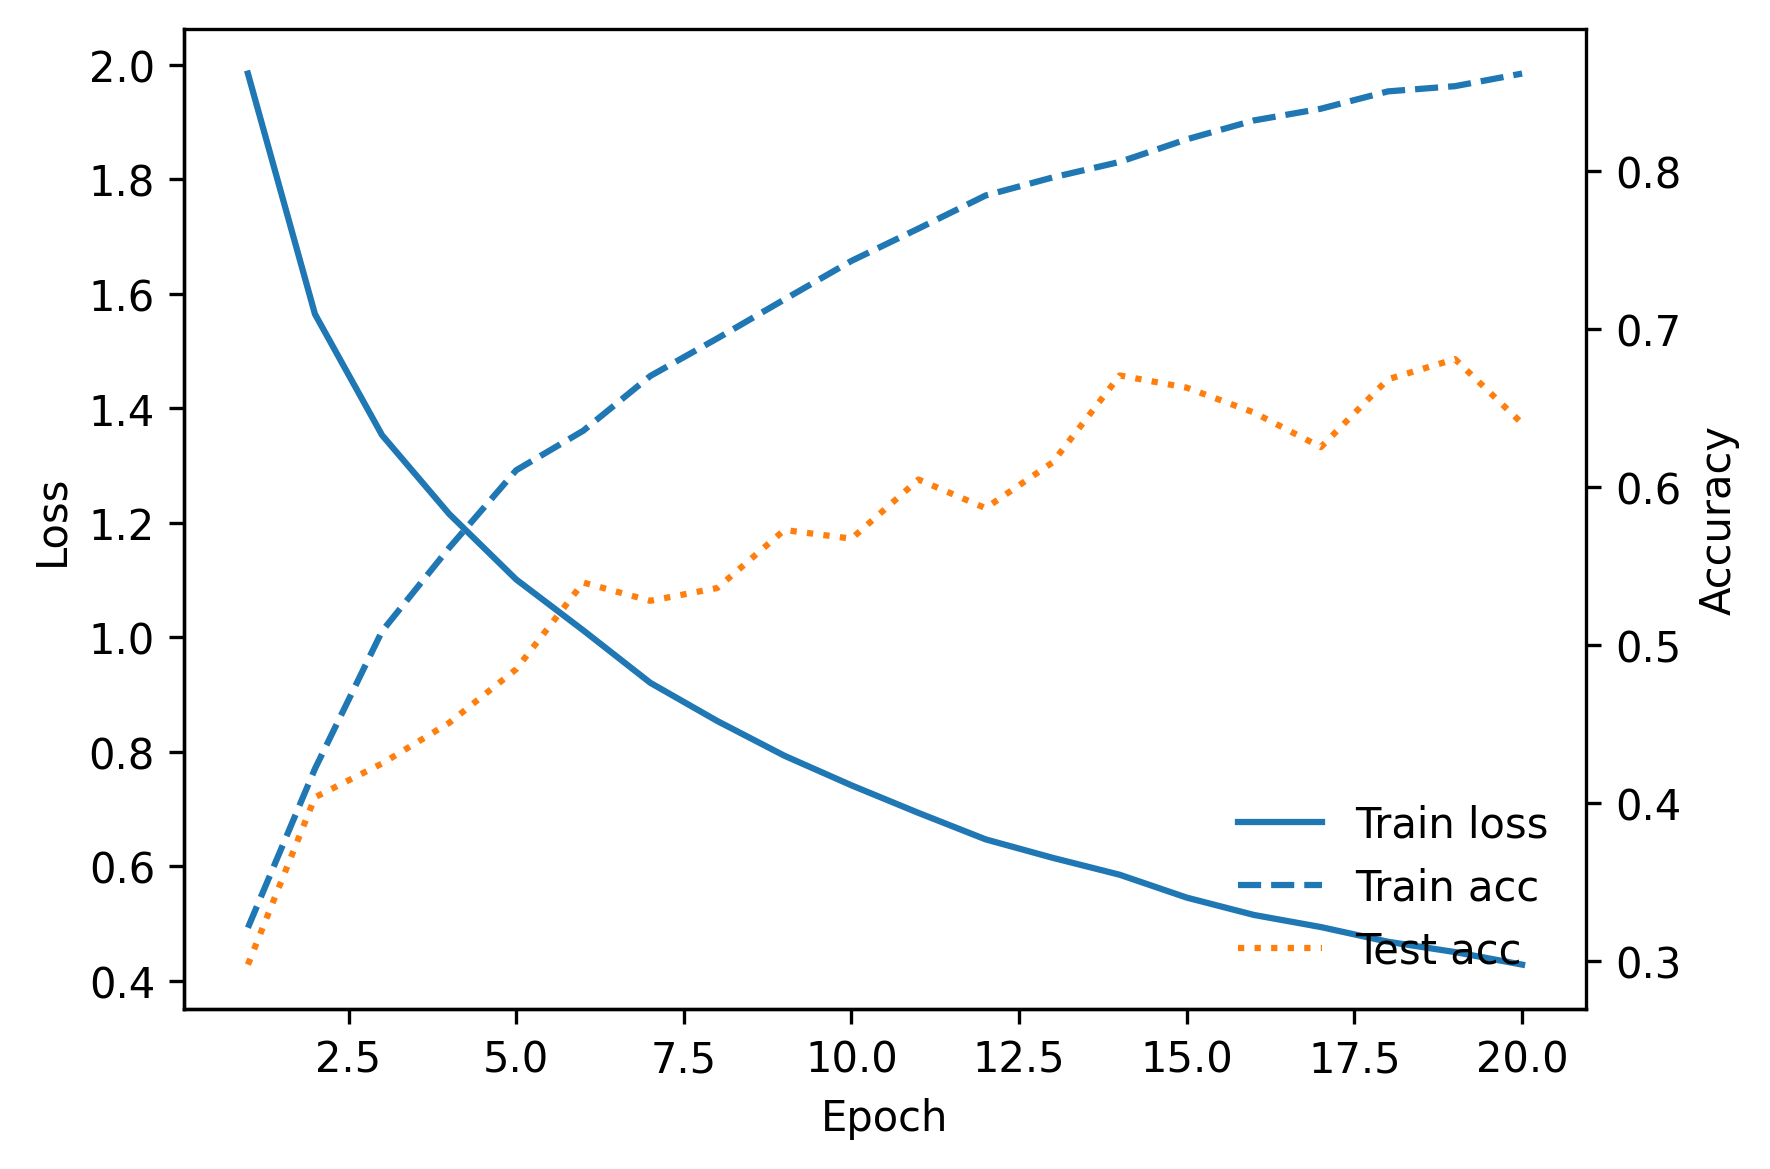

In [42]:
import matplotlib.pyplot as plt
from pathlib import Path

plot_dbn_curves(tl, ta, tsa, save_path=r"result\figs\testdbn_all_feature_training.png")


In [ ]:
传统DBN+手动提取的特征

改进方向：数据集的设计，分离训练集和测试集。

先把背景铺垫清楚一些，如果解决跨工况的问题，就换载荷。

如果不解决，就混着？应该要跨工况诊断吧。采样频率的信息也要设计下实验。特征组合也要设计下。

后续跑了一个baseline之后，基础结果应该是有优化空间的。在基础上设计注意力机制模块，以及融入cnn-dbn的模块，都看下效果呢.

数据方面的实验：

从数据筛选到特征处理 到模型改变 希望看到效果是逐步提升的

数据集 = 【‘单工况训练-跨工况预测’、‘跨工况训练-跨工况预测’】

训练测试划分 = 【‘分割训练和测试来自不同编号’、‘混着一起’】

特征集 = 【‘时域特征’、‘频域特征’、‘包络时域特征’、‘包络频域特征’、‘时频特征’】

模型集 = 【‘传统机器学习模型’】

创新模型集 = 【‘经典的bdn’】